# POC 02 — training, window reconstruction and aligned prototypes

This notebook is self-contained: world → sensors → **training grid** → sanity → window
reconstruction → aligned prototypes → invariance. Any cell missing from the store trains
here; cells already in the store are cache reads.

The previous version found that single windows decode flat (`window_amp` ≈ 0.03). Its §8
traced this to three things:
* **Undertraining:** about 35 Adam steps per client.
* **A dominant prototype term:** 69% of the loss.
* **A position signal that was not learned:** η² lift was identical at round −1.

This version tests the fixes.

| module | what it adds |
|---|---|
| `specs` | `training.proto_weight` (upstream knob) and `LossTerms` (lab-side objective) |
| `train` | `_local_update_lab`, `untrained_model` (round −1), `equivalence_check` |
| `aligned` | controls on every window, `invariance`, `sanity`, `plot_losses` |
| `winrec` | per-window scores, overlap-add timeline, window browser |

**Needs** the patched `fl_training/federated.py` for the `up pw0` cell. Without it, that cell
is refused with a message and the lab cells still run.

## 0. Setup

In [1]:
import sys, pathlib, time
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

REPO = next((p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
             if (p / "src" / "fedwater").is_dir()), None)
assert REPO is not None, "run this from inside the fedwater repo"
LAB_DIR = REPO / "notebooks" / "fedwater_lab_refactor"
for p in (REPO / "src", LAB_DIR):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from fedwater_lab.worlds import load_world, list_worlds, pick_world
from fedwater_lab.store import Store
from fedwater_lab.specs import POC, Geometry, LossTerms
from fedwater_lab.runner import run_cell
from fedwater_lab import data as D, recon as RC, train as T
from fedwater_lab import aligned as AL, winrec as WR

EXPERIMENTS = REPO / "data" / "09_experiments"
pd.set_option("display.width", 220, "display.max_columns", 40)

## 1. World and sensors

The selection is the same as POC_01 / the first POC_02 run, so the `base` cell below is a
cache read of that run.

In [ ]:
FILTERS = dict(sim_hash="ece8f4ad92e5", placement_source="dynamic")
world = load_world(pick_world(EXPERIMENTS, **FILTERS))
store = Store(LAB_DIR / "lab_sandbox")
print(world.summary().to_string())

SELECTION = dict(kinds=("flow",), classes=("pure", "mixed"), include=(), exclude=())

BASE = POC.with_(**SELECTION)

kept = D.sensor_table(world, BASE)
why = ["district", "slot", "slot_class", "sensor", "tier", "purity", "second", "w_second"]
display(kept[[c for c in why if c in kept.columns]].round(3))

sim_hash                                 ece8f4ad92e5
tag                 District_A__LR_LR_LR_LR__baseline
network                                          ky72
districting                                  spectral
partition_id                                 29fddafe
placement_source                              dynamic
n_months                                           65
resolution_h                                        1
steps_day                                          24
clients                                             4
n_sensors                                          32
n_pure                                             16
n_mixed                                            16
drift_district                             District_A
warmup_months                                      12
first_switch                                       12
last_switch                                        63
ramp_days                                         7.0
init_months                 

,district,slot,slot_class,sensor,tier,purity,second,w_second
0,District_A,q_mixed_0,mixed,q_P-558,foreign,0.000,District_B,0.725
1,District_A,q_mixed_1,mixed,q_P-10,transition,0.272,District_D,0.728
2,District_A,q_pure_0,pure,q_P-42,core,1.000,NaN,0.000
3,District_A,q_pure_1,pure,q_P-556,core,1.000,NaN,0.000
4,District_B,q_mixed_0,mixed,q_P-605,foreign,0.000,District_A,0.656
5,District_B,q_mixed_1,mixed,q_P-588,transition,0.477,District_C,0.263
6,District_B,q_pure_0,pure,q_P-30,core,1.000,NaN,0.000
7,District_B,q_pure_1,pure,q_P-285,core,1.000,NaN,0.000
8,District_C,q_mixed_0,mixed,q_P-518,transition,0.437,District_B,0.290
9,District_C,q_mixed_1,mixed,q_P-521,transition,0.254,District_B,0.378


## 2. Training grid

**Two ways to change the objective:**

* **Upstream:** `training.proto_weight` $=\lambda$ gives
  `loss = aer_loss + λ · proto_loss`, read by the patched `FPLTrainer`. Leaving it unset keeps
  the protocol unchanged, and the run key is unchanged too.
* **Lab:** `loss_terms=LossTerms(...)` makes the lab re-implement `_local_update`:

$$\mathcal{L} = \mathcal{L}_{AER} + \lambda_p\,\mathcal{L}_{proto}\,[r \ge r_0]
+ \lambda_d\,\mathrm{MSE}(\partial_t \hat x, \partial_t x)
+ \lambda_s\,\mathrm{MSE}(|\mathcal{F}\hat y|, |\mathcal{F} y|)
+ \lambda_v\,\tfrac{1}{d}\textstyle\sum_j \mathrm{relu}(\gamma - \sigma_{batch}(z_j))$$

where:
* $\partial_t$ is the first difference over the full window.
* $\mathcal{F}$ is the orthonormal FFT over steps $1..W-2$, applied after removing each
  window's mean.
* $\sigma_{batch}$ is the per-dimension std of the latent over the batch.

A flat reconstruction pays the target's full derivative energy ($\lambda_d$) and spectral
energy ($\lambda_s$), which is exactly what the flat-line minimum hides. The variance hinge
($\lambda_v$, VICReg) keeps latent dimensions spread against the prototype pull.
`LossTerms()` reproduces upstream bit for bit, and the check below asserts it on this world's
windows.

`long` is 30 rounds × 5 local epochs, about 1,050 Adam steps per client against about 35 for
`base`. Fill `TRAIN` with the cells to (re)train. Cells already in the store are skipped.

In [3]:
LONG = {"training.rounds": 30, "training.local_epochs": 5}
CELLS = {
    "base":             BASE,
    "long":             BASE.with_(**LONG),
    "long·up pw0":      BASE.with_(**LONG, **{"training.proto_weight": 0.0}),
    "long·lab pw0":     BASE.with_(**LONG, loss_terms=LossTerms(proto_weight=0.0)),
    "long·lab pw.1+d":  BASE.with_(**LONG, loss_terms=LossTerms(proto_weight=0.1, diff=1.0)),
    "long·lab pw.1+s":  BASE.with_(**LONG, loss_terms=LossTerms(proto_weight=0.1, spec=1.0)),
    "long·lab v":       BASE.with_(**LONG, loss_terms=LossTerms(var=1.0, var_gamma=0.1)),
}
TRAIN = list(CELLS)

display(pd.DataFrame([{"cell": k, "label": s.label(),
                       "in store": store.exists(world, s)} for k, s in CELLS.items()]))

,cell,label,in store
0,base,fmp__none__minmax_ref__a3w84s12__u30r5s0,True
1,long,fmp__none__minmax_ref__a3w84s12__u30r30e5s0,False
2,long·up pw0,fmp__none__minmax_ref__a3w84s12__u30r30e5pw0s0,False
3,long·lab pw0,fmp__none__minmax_ref__a3w84s12__u30r30e5s0__Lp0,False
4,long·lab pw.1+d,fmp__none__minmax_ref__a3w84s12__u30r30e5s0__L...,False
5,long·lab pw.1+s,fmp__none__minmax_ref__a3w84s12__u30r30e5s0__L...,False
6,long·lab v,fmp__none__minmax_ref__a3w84s12__u30r30e5s0__Lv1,False


### 2a. Lab loop equals upstream

This trains 2 short rounds on CPU with this world's windows and compares final weights and
every local prototype:
* upstream against `LossTerms()`;
* upstream `proto_weight=0` against `LossTerms(proto_weight=0)`.

Both must be `identical`. On GPU the two paths can still differ in the last digits (cuDNN), so
their long runs are compared on the metrics, not bit for bit.

In [4]:
fw0, _, fl0 = D.build_windows(world, BASE, cache=D.CACHE)
EQ = T.equivalence_check(fw0, fl0, seed=0, rounds=2)
display(EQ)
assert EQ["identical"].iloc[0], "lab loop diverges from upstream"

,pair,max_abs_weight_diff,max_abs_proto_diff,identical
0,upstream vs LossTerms(),0.0,0.0,True
1,upstream pw=0 vs LossTerms(proto_weight=0),0.0,0.0,True


In [5]:
RUNS = {}
for name in TRAIN:
    spec = CELLS[name]
    t0 = time.time()
    try:
        res = run_cell(world, spec, store=store, verbose=True)
    except RuntimeError as exc:           # e.g. upstream proto_weight without the patch
        print(f"{name:<18} REFUSED: {exc}")
        continue
    RUNS[name] = res["run_key"]
    print(f"{name:<18} {res['run_key']}  cache_hit={res['cache_hit']}  "
          f"{time.time() - t0:.0f}s")

  cached  fmp__none__minmax_ref__a3w84s12__u30r5s0  [3675c1f38427]
base               3675c1f38427  cache_hit=True  0s
  round   0  loss 0.39559  online 4
  round   1  loss 1.24740  online 4
  round   2  loss 1.22392  online 4
  round   3  loss 1.19467  online 4
  round   4  loss 1.18221  online 4
long               ebf14537cde1  cache_hit=False  8s
  round   0  loss 0.39559  online 4
  round   1  loss 1.24740  online 4
  round   2  loss 1.22392  online 4
  round   3  loss 1.19467  online 4
  round   4  loss 1.18221  online 4
long·up pw0        24403632d296  cache_hit=False  7s
  round   0  loss 0.39559  online 4
  round   1  loss 0.38745  online 4
  round   2  loss 0.37871  online 4
  round   3  loss 0.36821  online 4
  round   4  loss 0.35855  online 4
long·lab pw0       91e9ca3d8e16  cache_hit=False  9s
  round   0  loss 0.89056  online 4
  round   1  loss 0.96325  online 4
  round   2  loss 0.96485  online 4
  round   3  loss 0.94408  online 4
  round   4  loss 0.93887  online 4
lo

## 3. Sanity, per cell

Each cell is decoded and checked against the **untrained control**. That is the round −1
model, rebuilt from the seed and asserted equal to the saved round −1 snapshot, and it is
applied to every window.

| column | meaning |
|---|---|
| `steps/client` | rounds × local epochs × batches |
| `d_mse_last` | relative change of `loss_mse` at the last round; < 0 means still learning |
| `proto_share` | `loss_proto` / total loss, last round |
| `final_over_wmean` | final AER loss / best flat line (each window's own mean); < 1 means shape is captured |
| `window_amp`, `window_r` | median $\sigma_t(\hat x)/\sigma_t(x)$ and $\mathrm{corr}_t(\hat x, x)$ per window |
| `level_r` | $\mathrm{corr}_w$ of window means, decoded vs true |
| `eta_lift_final` / `_ctrl` | §4 η² lift (time-of-day key), trained vs untrained, all windows |
| `rel_block_first/last` | within-month latent spread / latent norm, first and last snapshot |
| `ctrl_window_amp` | the same amplitude score for the untrained model |

This takes about a minute per cell (decoding, permutations, control).

,base,long,long·up pw0,long·lab pw0,long·lab pw.1+d,long·lab pw.1+s,long·lab v
label,fmp__none__minmax_ref__a3w84s12__u30r5s0,fmp__none__minmax_ref__a3w84s12__u30r30e5s0,fmp__none__minmax_ref__a3w84s12__u30r30e5pw0s0,fmp__none__minmax_ref__a3w84s12__u30r30e5s0__Lp0,fmp__none__minmax_ref__a3w84s12__u30r30e5s0__L...,fmp__none__minmax_ref__a3w84s12__u30r30e5s0__L...,fmp__none__minmax_ref__a3w84s12__u30r30e5s0__Lv1
run_key,3675c1f38427,ebf14537cde1,24403632d296,91e9ca3d8e16,028ca9bf44b3,949895d5bea0,79139ce2449a
steps/client,35,35,35,35,35,35,35
loss_mse_last,0.365842,0.365842,0.365842,0.358549,0.360394,0.363321,0.364753
d_mse_last,-0.020736,-0.020736,-0.020736,-0.026228,-0.024285,-0.01949,-0.021714
proto_share,0.690543,0.690543,0.690543,0.0,0.874741,1.084648,0.655297
final_over_wmean,1.314404,1.314404,1.314404,1.297215,1.303541,1.311211,1.311078
final_over_const,1.130924,1.130924,1.130924,1.117765,1.12358,1.133049,1.128887
window_amp,0.028651,0.028651,0.028651,0.02698,0.027418,0.047424,0.028582
window_r,0.00011,0.00011,0.00011,-0.01404,-0.010248,0.001765,-0.00123


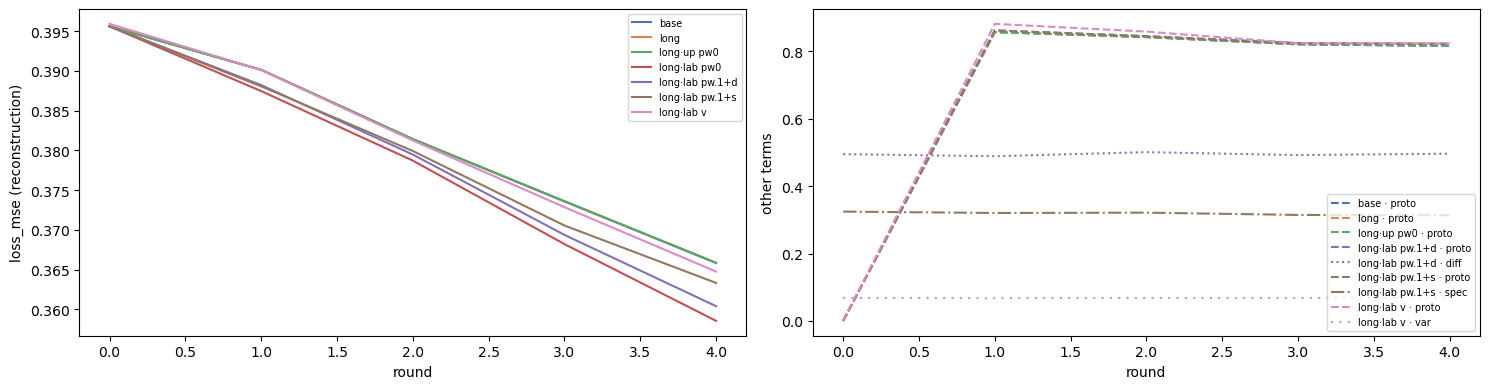

In [6]:
ALIGN24 = AL.Alignment(period_h=24, bin_h=None, block=1)
OUTS, SAN = {}, {}
for name in RUNS:
    OUTS[name] = AL.analyse(world, CELLS[name], ALIGN24, store=store, server=False, n_perm=99)
    SAN[name] = AL.sanity(world, OUTS[name], n_perm=99)
    assert OUTS[name]["checks"]["passed"].all(), OUTS[name]["checks"]
    assert SAN[name]["control_check"]["passed"].all(), SAN[name]["control_check"]

SANITY = pd.DataFrame({k: v["row"] for k, v in SAN.items()})
display(SANITY)

fig, ax = plt.subplots(1, 2, figsize=(15, 4))
AL.plot_losses(ax, {k: OUTS[k]["res"]["training_log"] for k in OUTS})
fig.tight_layout()
plt.show()

## 4. Focus cell

Everything below reads one cell. The objects are:
* `run`: the trained model on every window, keyed by time of day.
* `ctrl`: the same for the untrained model.
* `channels`: slot, class and mixture label of each channel.

In [14]:
FOCUS = "long·up pw0" #"long"
out, san = OUTS[FOCUS], SAN[FOCUS]
run, ctrl, fw, model = out["run"], san["control"], out["fw"], out["model"]
spec_f = CELLS[FOCUS]
channels = RC.channel_table(world, fw)
print(spec_f.label())
display(channels)

fmp__none__minmax_ref__a3w84s12__u30r30e5pw0s0


,client,channel,slot,sensor,kind,slot_class,w_District_A,w_District_B,w_District_C,w_District_D
0,District_A,0,q_mixed_0,q_P-558,flow,mixed,0.000000,0.724639,0.275361,0.000000
1,District_A,1,q_mixed_1,q_P-10,flow,mixed,0.272429,0.000000,0.000000,0.727571
2,District_A,2,q_pure_0,q_P-42,flow,pure,1.000000,0.000000,0.000000,0.000000
3,District_A,3,q_pure_1,q_P-556,flow,pure,1.000000,0.000000,0.000000,0.000000
4,District_B,0,q_mixed_0,q_P-605,flow,mixed,0.656441,0.000000,0.343559,0.000000
5,District_B,1,q_mixed_1,q_P-588,flow,mixed,0.259996,0.476966,0.263038,0.000000
6,District_B,2,q_pure_0,q_P-30,flow,pure,0.000000,1.000000,0.000000,0.000000
7,District_B,3,q_pure_1,q_P-285,flow,pure,0.000000,1.000000,0.000000,0.000000
8,District_C,0,q_mixed_0,q_P-518,flow,mixed,0.272517,0.290256,0.437227,0.000000
9,District_C,1,q_mixed_1,q_P-521,flow,mixed,0.368882,0.377574,0.253544,0.000000


## 5. Window reconstruction

Scores are computed per window and per channel. The AER encodes all channels of a window
jointly, so a channel's reconstruction is a slice of one output.

* `rmse` $=\sqrt{\mathrm{mean}_t(\hat x - x)^2}$
* `r` $=\mathrm{corr}_t(\hat x, x)$
* `amp` $=\sigma_t\hat x / \sigma_t x$
* `lvl` $=\overline{\hat x} - \bar x$

The tables are medians per phase × slot class, for the trained model and the untrained one.
The grids show the median `r` over month × start class (weekday·hour, with weekday = day mod 7
from step 0, as in the demand model). A row that stays pale across months is a calendar class
the model does not reconstruct.

In the browser, the top panel is one window with its reconstruction (and the untrained one if
selected). The bottom panel is the **overlap-add** timeline: each step is the mean of every
covering window's reconstruction at that step, drawn against the true series, with
weekday 5–6 shaded.

phase slot_class   rmse      r    amp    lvl     n
trained   0        init      mixed  0.603  0.006  0.011 -0.010   568
          1        init       pure  0.637  0.001  0.036 -0.198   568
          2  transition      mixed  0.592  0.003  0.013  0.008  2496
          3  transition       pure  0.621 -0.001  0.044 -0.080  2496
          4       final      mixed  0.554  0.026  0.014  0.037    32
          5       final       pure  0.638 -0.000  0.045 -0.079    32
untrained 0        init      mixed  0.605  0.047  0.001 -0.087   568
          1        init       pure  0.600 -0.013  0.003  0.004   568
          2  transition      mixed  0.598  0.038  0.001 -0.013  2496
          3  transition       pure  0.605 -0.012  0.002  0.133  2496
          4       final      mixed  0.554  0.033  0.001  0.008    32
          5       final       pure  0.611 -0.028  0.002  0.135    32

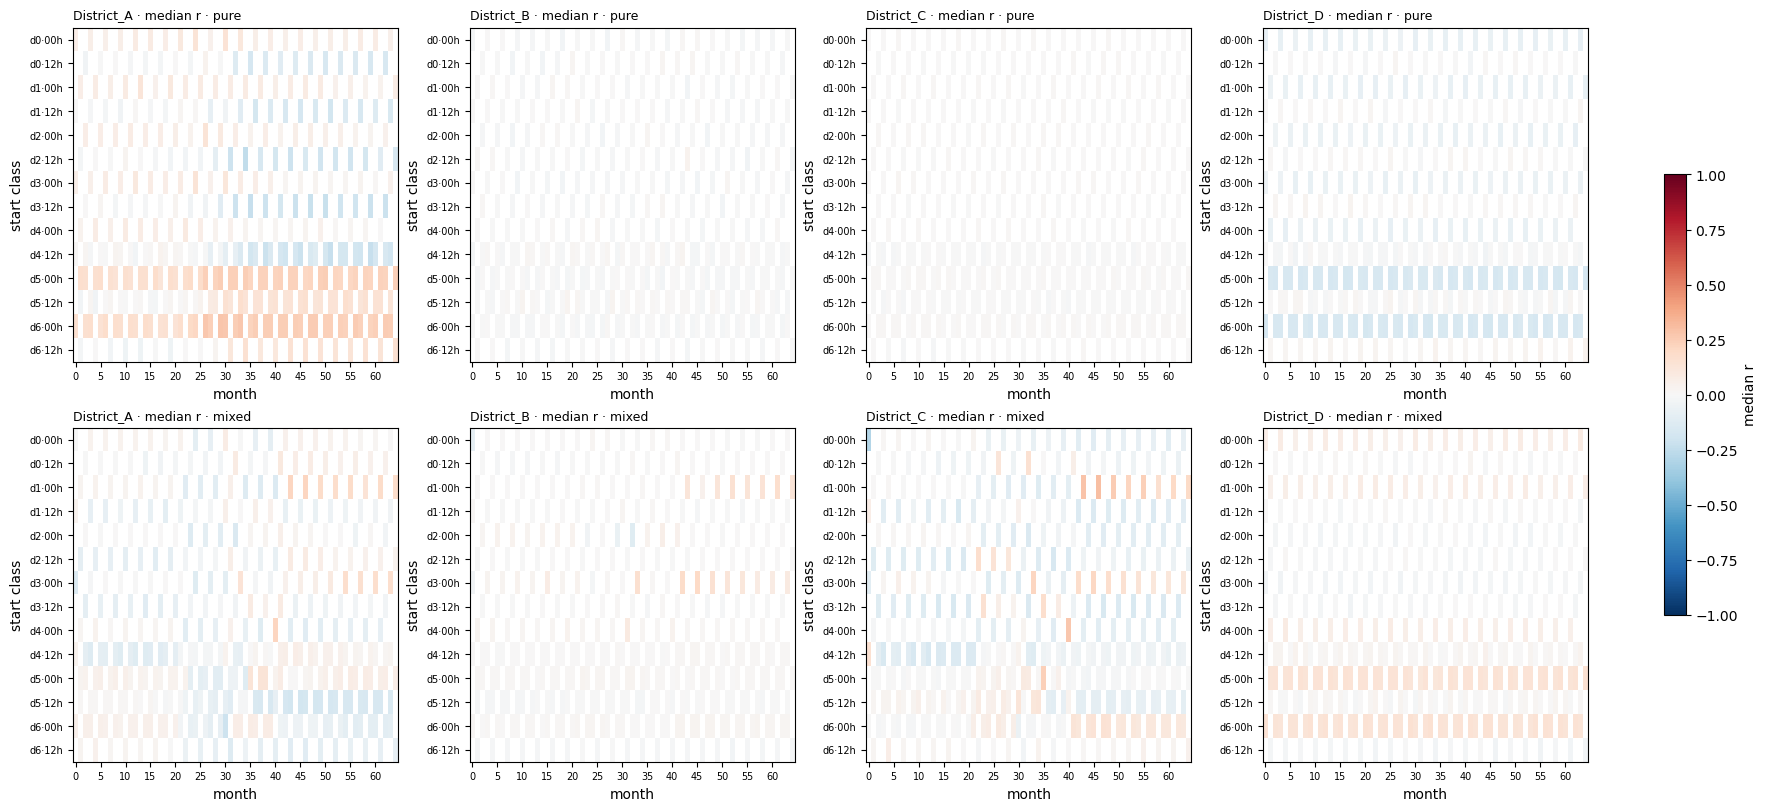

In [15]:
WS = WR.window_scores(run, fw, channels)
WS_C = WR.window_scores(ctrl, fw, channels)
display(pd.concat({"trained": WR.score_summary(WS), "untrained": WR.score_summary(WS_C)})
          .round(3))

clients = world.client_names
fig, axes = plt.subplots(2, len(clients), figsize=(4.4 * len(clients), 8), squeeze=False,
                         layout="constrained")
for j, c in enumerate(clients):
    for i, cls in enumerate(("pure", "mixed")):
        im = WR.plot_score_grid(axes[i, j], WS, c, "r", cls)
fig.colorbar(im, ax=axes, shrink=0.6, label="median r")
plt.show()

In [16]:
_ = WR.window_browser(run, fw, WS, channels, ctrl=ctrl)

## 6. Weekday × hour prototypes

The key is $P = 168$ h with no bin. With a 36 h stride, start positions take exactly 14 values,
one per weekday × {00h, 12h}. Every window is 10.5 days long, so every window contains a
weekend. The class fixes *where* the weekend sits in the window, which is why averaging within
a class keeps the weekly shape. Classes are pooled per phase (`block="phase"`): about 5
windows per class in init, and very few in this world's one-month `final`.

In the browser, use `period = init` to see each class's decoded prototype against its aligned
true mean, and `all cycle positions` to see all 14 classes at once.

phase,init,transition,final
cycle,,,
d0·00h,4.0,18.0,NaN
d0·12h,4.0,17.0,NaN
d1·00h,4.0,17.0,1.0
d1·12h,4.0,18.0,NaN
d2·00h,4.0,17.0,NaN
d2·12h,4.0,17.0,1.0
d3·00h,4.0,18.0,NaN
d3·12h,4.0,17.0,NaN
d4·00h,4.0,17.0,NaN


,source,phase,rmse,r_shape,amp,r2_dem,n
0,true,init,0.000,1.000,1.000,0.731,224
1,true,transition,0.000,1.000,1.000,0.766,224
2,true,final,0.000,1.000,1.000,0.700,64
3,aligned,init,0.620,-0.000,0.025,0.005,224
4,aligned,transition,0.539,0.002,0.030,0.008,224
5,aligned,final,0.608,0.023,0.029,0.013,64
6,ceiling,init,0.620,-0.000,0.025,0.005,224
7,ceiling,transition,0.539,0.003,0.030,0.008,224
8,ceiling,final,0.608,0.023,0.029,0.013,64
9,pooled,init,0.620,0.002,0.025,0.005,224


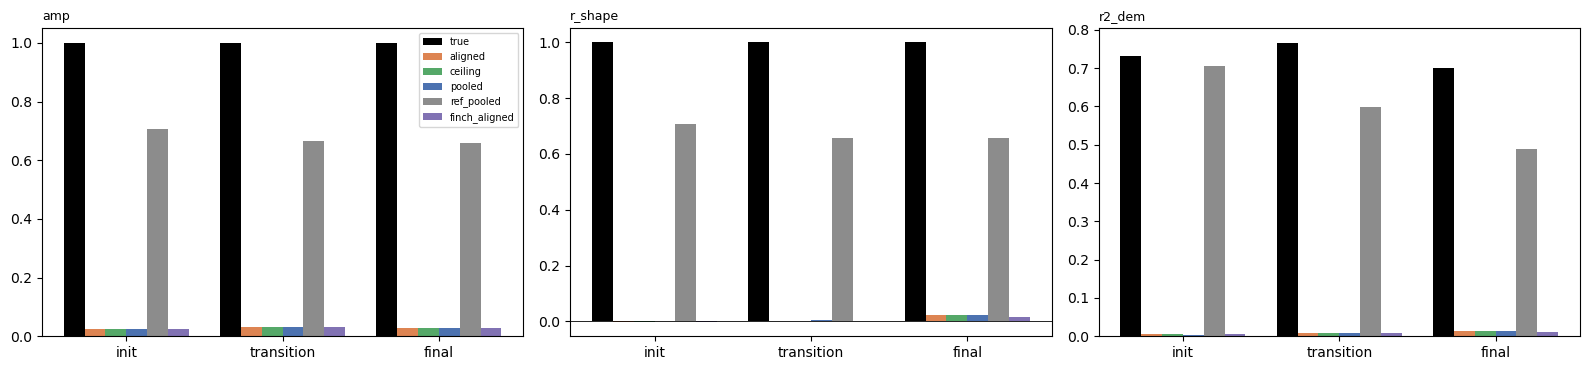

In [10]:
ALIGN168 = AL.Alignment(period_h=168, bin_h=None, block="phase")
OUT168 = AL.analyse(world, spec_f, ALIGN168, store=store, server=True, n_perm=99)
assert OUT168["checks"]["passed"].all()
cov = OUT168["coverage"]
display(cov.pivot_table(index="cycle", columns="phase", values="n_min")
           .reindex(columns=[p for p in RC.PERIODS if p in set(cov["phase"])]))
display(OUT168["summary"].round(3))
fig, ax = plt.subplots(1, 3, figsize=(16, 3.8))
AL.plot_ladder_summary(ax, OUT168["summary"])
fig.tight_layout()
plt.show()

In [11]:
_ = AL.aligned_browser(OUT168["run"], OUT168["fid"], channels)

## 7. Invariance across blocks

For each client, class $g$ (weekday·hour), block $b$ (6 months within a phase) and channel $i$,
the block is compared with the **init** reference of the same class. The reference leaves out
the block's own months when the block lies inside init.

* `r_true` $=\mathrm{corr}_t(T_{b,g,i}, T_{ref,g,i})$ and `lvl_true`: does the *data* keep
  the class shape and level? This is the target, independent of any model.
* `d_lat` $= 1-\cos(z_{b,g}, z_{ref,g})$ and `e_lat` $=\lVert z_{b,g}-z_{ref,g}\rVert /
  \lVert z_{ref,g}\rVert$: does the *representation* move? Read these trained **against
  untrained**.
* `r_dec` $=\mathrm{corr}_t(\hat T_{b,g,i}, \hat T_{ref,g,i})$ on decoded mean latents, and
  `r_fid` $=\mathrm{corr}_t(\hat T_{b,g,i}, T_{b,g,i})$: does the decoded class move with the
  data, and does it look like it at all?

**Expected on this world:**
* pure channels of B, C and D stay at `r_true` ≈ 1;
* A departs through the transition;
* mixed channels that listen to A depart in proportion to their A weight.

With about 0.4 windows per class per month, a 6-month block holds about 2.6 windows per class,
so single cells are noisy and the summaries average over classes and channels.

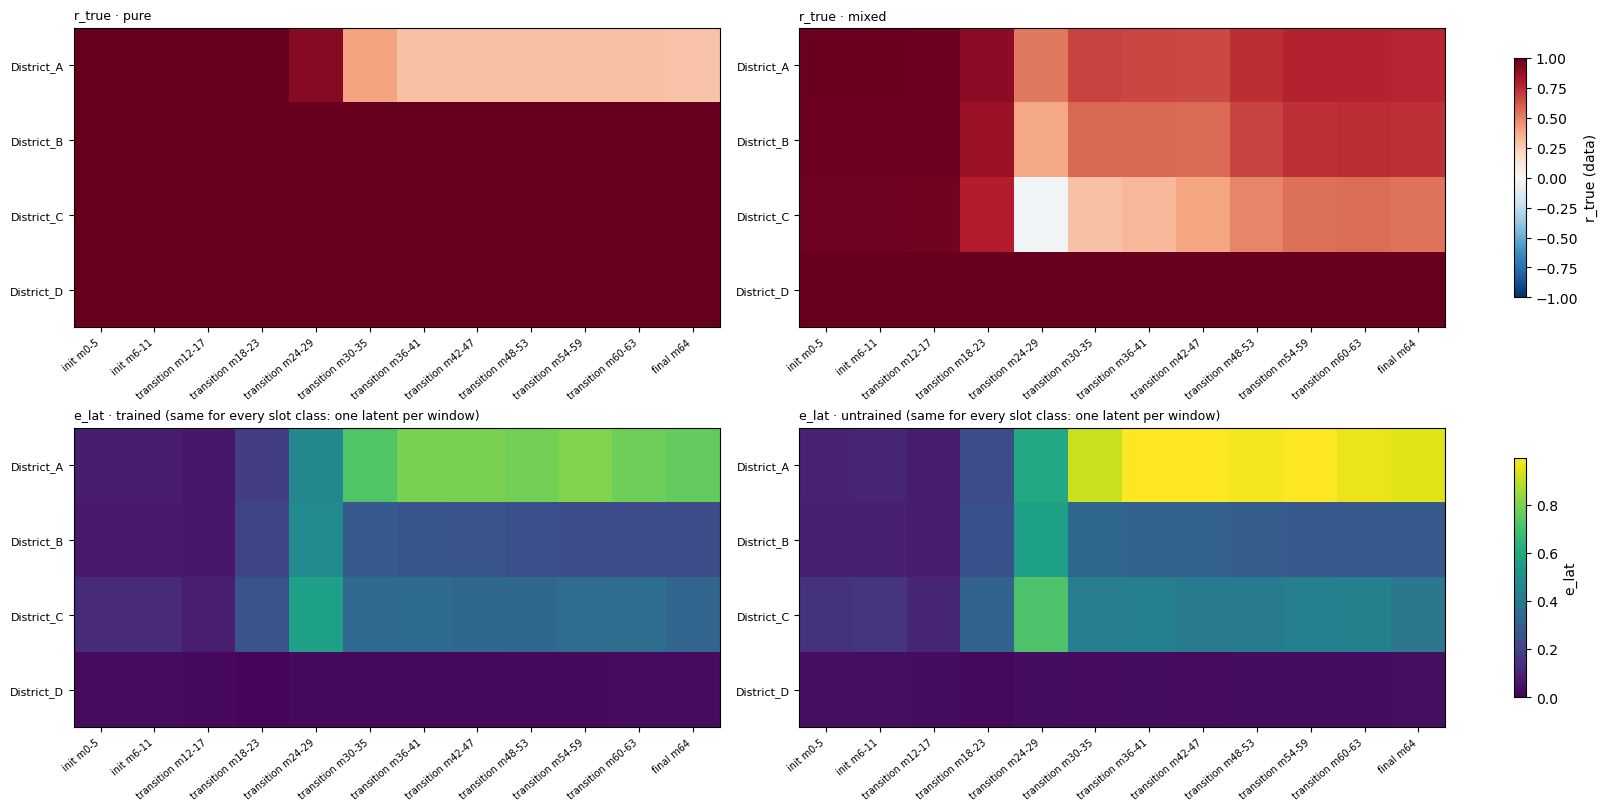

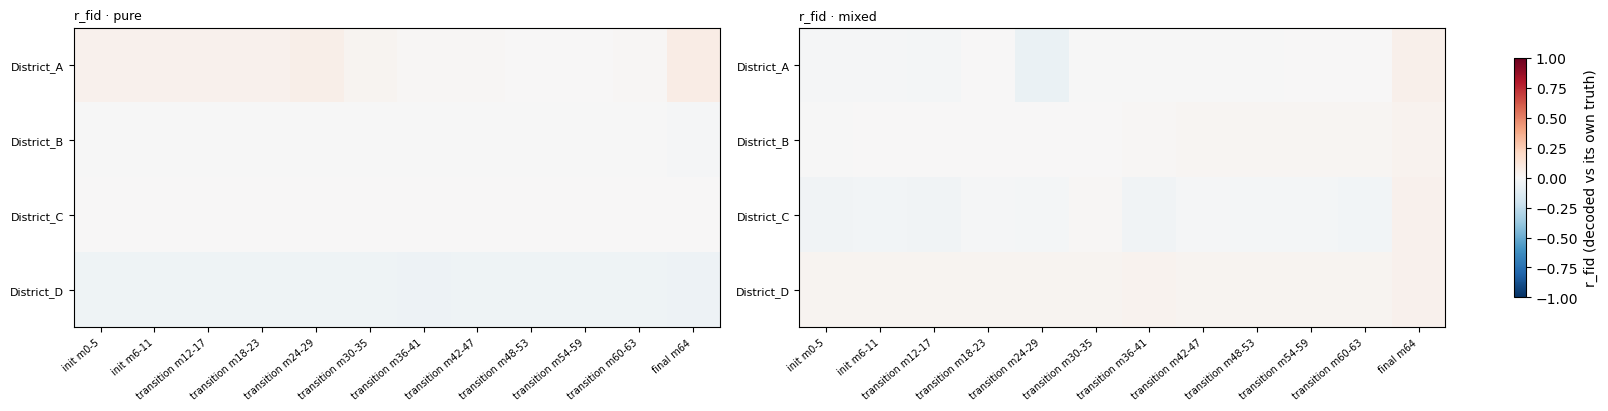

e_lat                    r_dec                    r_fid                   r_true                  
phase                  final   init transition  final   init transition  final   init transition  final   init transition
client     slot_class                                                                                                    
District_A mixed       0.757  0.078      0.598  0.799  0.954      0.665  0.048 -0.010     -0.010  0.761  0.986      0.742
           pure        0.757  0.078      0.598  1.000  1.000      1.000  0.075  0.043      0.023  0.286  0.994      0.530
District_B mixed       0.230  0.072      0.251  0.904  0.999      0.932  0.032  0.002      0.013  0.729  0.982      0.677
           pure        0.230  0.072      0.251  1.000  1.000      1.000 -0.009 -0.003     -0.004  0.995  0.996      0.997
District_C mixed       0.325  0.119      0.331  0.752  0.917      0.696  0.040 -0.030     -0.019  0.547  0.970      0.481
           pure        0.325  0.119      0.331  1.000  1.000      1.000  0.005  0.004      0.004  0.995  0.994      0.996
District_D mixed       0.030  0.029      0.024  1.000  0.997      0.999  0.047  0.028      0.029  0.999  0.998      0.999
           pure        0.030  0.029      0.024  1.000  1.000      1.000 -0.053 -0.043     -0.045  0.999  0.998      0.999

In [12]:
BLOCK = 6
INV = AL.invariance(world, run.wt, fw, model, channels, block=BLOCK)
INV_C = AL.invariance(world, ctrl.wt, fw, None, channels, block=BLOCK)
S_T, S_C = AL.invariance_summary(INV), AL.invariance_summary(INV_C)

fig, axes = plt.subplots(2, 2, figsize=(16, 8), layout="constrained")
for j, cls in enumerate(("pure", "mixed")):
    im = AL.plot_invariance(axes[0, j], S_T, "r_true", cls, vmin=-1, vmax=1)
fig.colorbar(im, ax=axes[0], shrink=0.8, label="r_true (data)")
vmax = float(np.nanpercentile(pd.concat([S_T["e_lat"], S_C["e_lat"]]), 98))
for j, (name, S) in enumerate((("trained", S_T), ("untrained", S_C))):
    im = AL.plot_invariance(axes[1, j], S, "e_lat", "pure", vmin=0, vmax=vmax,
                            cmap="viridis")
    axes[1, j].set_title(f"e_lat · {name} (same for every slot class: one latent "
                         "per window)", fontsize=9, loc="left")
fig.colorbar(im, ax=axes[1], shrink=0.8, label="e_lat")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 4), layout="constrained")
for j, cls in enumerate(("pure", "mixed")):
    im = AL.plot_invariance(axes[j], S_T, "r_fid", cls, vmin=-1, vmax=1)
fig.colorbar(im, ax=axes, shrink=0.8, label="r_fid (decoded vs its own truth)")
plt.show()

display(S_T.pivot_table(index=["client", "slot_class"], columns="phase",
                        values=["r_true", "r_dec", "r_fid", "e_lat"])
           .round(3))

## 8. Latent diagnostics of the focus cell

These are the §8 tables of the first run for this cell: loss by round, the loss against flat
baselines, decoder levels, η² per snapshot round (round −1 = control), and the spread per
round.

In [13]:
for k in ("loss", "baselines"):
    display(san[k].round(4))
display(san["levels"].groupby(["client", "phase"])[["level_r", "level_ratio", "shape_amp"]]
          .mean().round(3))
display(san["eta"].pivot_table(index=["round", "stage"], columns="phase", values="lift",
                               sort=False).round(3))
display(san["spread"].round(4))

,round,loss,loss_mse,loss_proto,d_mse,proto_share
0,0,0.3956,0.3956,0.0000,NaN,0.0000
1,1,1.2474,0.3901,0.8573,-0.0138,0.6872
2,2,1.2239,0.3814,0.8425,-0.0224,0.6884
3,3,1.1947,0.3736,0.8211,-0.0205,0.6873
4,4,1.1822,0.3658,0.8164,-0.0207,0.6905


,client,n,loss_final,base_const,base_wmean,final_over_const,final_over_wmean
0,District_A,387,0.4390,0.4460,0.2646,0.9843,1.6593
1,District_B,387,0.3642,0.2947,0.2936,1.2359,1.2402
2,District_C,387,0.4025,0.3282,0.3142,1.2263,1.2809
3,District_D,387,0.3554,0.3300,0.3299,1.0771,1.0772


level_r  level_ratio  shape_amp
client     phase                                      
District_A final         0.359        0.559      0.037
           init          0.372        0.693      0.025
           transition    0.672        0.095      0.035
District_B final         0.299        0.692      0.028
           init          0.245        0.455      0.025
           transition    0.112        0.301      0.027
District_C final         0.530        0.512      0.026
           init          0.375        0.545      0.024
           transition    0.178        0.553      0.025
District_D final         0.928        0.447      0.025
           init          0.382        0.519      0.025
           transition    0.370        0.492      0.025

phase              all  final   init  transition
round     stage                                 
-1        pre    0.275  0.223  0.440       0.238
0         pre    0.276  0.224  0.443       0.239
          post   0.275  0.223  0.441       0.238
2         pre    0.274  0.215  0.441       0.236
          post   0.275  0.224  0.443       0.237
4         pre    0.272  0.209  0.441       0.235
          post   0.273  0.218  0.441       0.235
final_all post   0.276  0.218  0.441       0.239

,round,stage,n,norm,s_client,s_block,s_group,rel_block
0,-1,pre,1296,0.0821,0.0335,0.0277,0.0189,0.3377
1,0,post,1296,0.0850,0.0337,0.0279,0.0189,0.3278
2,0,pre,1296,0.0881,0.0344,0.0282,0.0192,0.3201
3,2,post,1296,0.0906,0.0324,0.0267,0.0182,0.2946
4,2,pre,1296,0.0899,0.0325,0.0263,0.0180,0.2926
5,4,post,1296,0.0966,0.0317,0.0259,0.0177,0.2684
6,4,pre,1296,0.0963,0.0319,0.0257,0.0176,0.2671
7,final_all,post,1548,0.0966,0.0318,0.0265,0.0187,0.2747


## What this leaves open

* **The decoder design.** The decoder receives the same latent vector at every step. In the
  harness, an undertrained decoder reproduces the first few steps and then settles to a
  constant, as an LSTM driven by constant input tends to do. If `long` still shows that shape
  in §5, the next axis is the architecture: feed the decoder a per-step time or phase encoding
  alongside $z$. That is an upstream `AER` change.
* **The drift window is short.** `final` is one month in this world, so the final side of §6
  and §7 rests on the transition blocks.
* **GPU equivalence.** `long·up pw0` and `long·lab pw0` are equivalent by construction and
  bit-identical on CPU (§2a). On GPU, compare them on the metrics.
* **Loss weights.** The loss-term weights are first guesses ($\lambda = 1$, $\gamma = 0.1$).
  Read §3 before sweeping them.